![digitizing_team](digitizing_team.png)


DigiNsure Inc. is an innovative insurance company focused on enhancing the efficiency of processing claims and customer service interactions. Their newest initiative is digitizing all historical insurance claim documents, which includes improving the labeling of some IDs scanned from paper documents and identifying them as primary or secondary IDs.

To help them in their effort, you'll be using multi-modal learning to train an Optical Character Recognition (OCR) model. To improve the classification, the model will use **images** of the scanned documents as input and their **insurance type** (home, life, auto, health, or other). Integrating different data modalities (such as image and text) enables the model to perform better in complex scenarios, helping to capture more nuanced information. The **labels** that the model will be trained to identify are of two types: a primary and a secondary ID, for each image-insurance type pair.

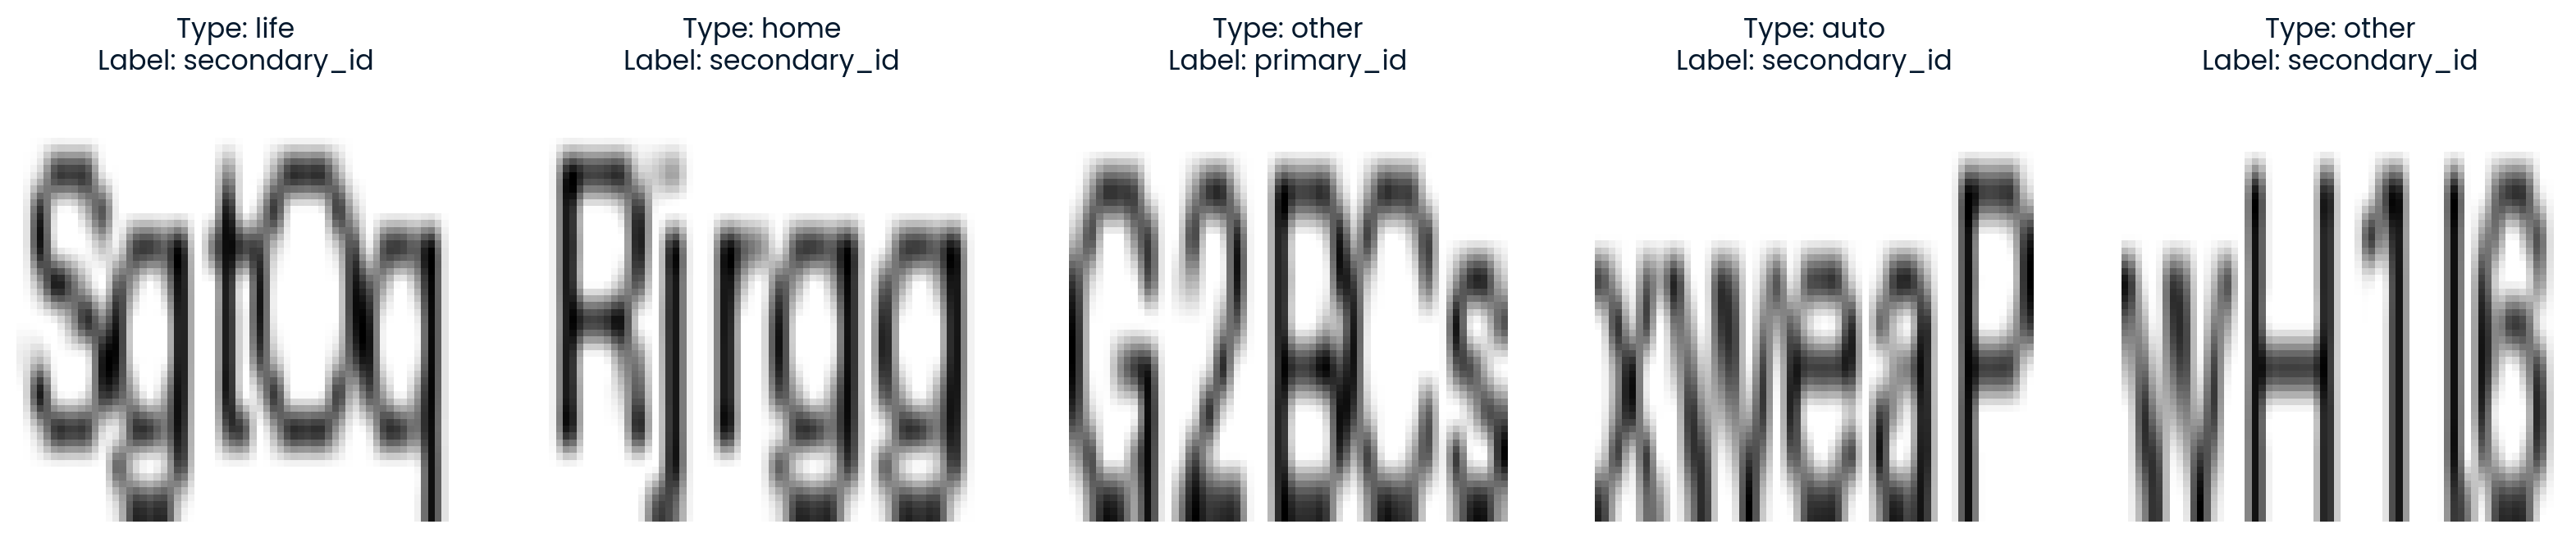

In [54]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from project_utils import ProjectDataset
import pickle 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Load the data
dataset = pickle.load(open('ocr_insurance_dataset.pkl', 'rb'))

# Define a function to visualize codes with their corresponding types and labels 
def show_dataset_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, min(num_images, len(dataset)), figsize=(20, 4))
    for ax, idx in zip(axes, np.random.choice(len(dataset), min(num_images, len(dataset)), False)):
        img, lbl = dataset[idx]
        ax.imshow((img[0].numpy() * 255).astype(np.uint8).reshape(64,64), cmap='gray'), ax.axis('off')
        ax.set_title(f"Type: {list(dataset.type_mapping.keys())[img[1].tolist().index(1)]}\nLabel: {list(dataset.label_mapping.keys())[list(dataset.label_mapping.values()).index(lbl)]}")
    plt.show()

# Inspect 5 codes images from the dataset
show_dataset_images(dataset)

In [55]:
class OCRModel(nn.Module):
    def __init__(self):
        super(OCRModel, self).__init__()
        
        # Image branch
        self.image_layer = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16*32*32, 128),
            nn.ReLU()
        )
        
        # Type branch
        self.type_layer = nn.Sequential(
            nn.Linear(5, 10),
            nn.ReLU()
        )
        
        # Classifier → output exactly 2 classes
        self.classifier = nn.Sequential(
            nn.Linear(128 + 10, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # 2 classes: Primary / Secondary
        )
        
    def forward(self, x_image, x_type):
        x_image = self.image_layer(x_image)
        x_type = self.type_layer(x_type.float())
        x = torch.cat((x_image, x_type), dim=1)
        x = self.classifier(x)
        return x

In [56]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = OCRModel().to(device)

# --- Optimizer ---
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Loss function ---
criterion = nn.CrossEntropyLoss()

In [57]:
from torch.utils.data import DataLoader

# Create DataLoader
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)


num_epochs = 40

for epoch in range(num_epochs):
    model.train()  
    running_loss = 0.0
    
    for (image, label) in train_loader:
        # Unpack image and type vector from the dataset
        x_image, x_type = image  
        x_image, x_type, label = x_image.to(device), x_type.to(device), label.to(device)
        
        optimizer.zero_grad()  # clear previous gradients
        
        # Forward pass
        outputs = model(x_image, x_type)  # shape: [B,64]
        
        outputs_for_loss = outputs[:, :2]
        
        # Compute loss
        loss = criterion(outputs_for_loss, label)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/40], Loss: 0.7279
Epoch [2/40], Loss: 0.8279
Epoch [3/40], Loss: 0.7263
Epoch [4/40], Loss: 0.6435
Epoch [5/40], Loss: 0.6915
Epoch [6/40], Loss: 0.7684
Epoch [7/40], Loss: 0.6799
Epoch [8/40], Loss: 0.6176
Epoch [9/40], Loss: 0.5954
Epoch [10/40], Loss: 0.5518
Epoch [11/40], Loss: 0.5092
Epoch [12/40], Loss: 0.5105
Epoch [13/40], Loss: 0.5184
Epoch [14/40], Loss: 0.4316
Epoch [15/40], Loss: 0.4310
Epoch [16/40], Loss: 0.3669
Epoch [17/40], Loss: 0.3825
Epoch [18/40], Loss: 0.3622
Epoch [19/40], Loss: 0.3064
Epoch [20/40], Loss: 0.2576
Epoch [21/40], Loss: 0.2042
Epoch [22/40], Loss: 0.1725
Epoch [23/40], Loss: 0.1532
Epoch [24/40], Loss: 0.1698
Epoch [25/40], Loss: 0.1657
Epoch [26/40], Loss: 0.1428
Epoch [27/40], Loss: 0.1094
Epoch [28/40], Loss: 0.1017
Epoch [29/40], Loss: 0.0822
Epoch [30/40], Loss: 0.0588
Epoch [31/40], Loss: 0.0619
Epoch [32/40], Loss: 0.0423
Epoch [33/40], Loss: 0.0456
Epoch [34/40], Loss: 0.0253
Epoch [35/40], Loss: 0.0267
Epoch [36/40], Loss: 0.0298
E

# -----------------------------------------